# FAQ Generation via Document Clustering - StudyChat Dataset

**Dataset**: StudyChat (wmcnicho/StudyChat on Hugging Face)  
**Goal**: Generate FAQs by clustering student prompts and computing representative centroids  
**Date**: February 2026

## Overview

This notebook uses **K-Means** and **Fuzzy C-Means (FCM)** clustering to:
1. Group similar student prompts into clusters
2. Compute cluster centroids representing typical questions
3. Generate FAQ entries from most representative prompts per cluster
4. Analyze question patterns by topic and difficulty levels

**Dataset Structure**:
- 16,851 student-tutor interactions
- Fields: prompt, response, topic, messages, llm_label, semester
- Topics: Assignments (a1-a4), conceptual questions, writing requests
- LLM labels: Question classification and justification

**Applications to TFG-Chatbot**:
- Difficulty estimation via labeled centroids
- Question classification by topic and type
- Automated FAQ generation for academic subjects
- Cross-lingual adaptation (StudyChat → Spanish TFG-Chatbot)

In [19]:
# Standard library imports
import json

# Custom implementations from math_investigation
import sys
from collections import defaultdict
from datetime import datetime
from pathlib import Path

# Visualization
import matplotlib.pyplot as plt

# Numerical computing
import numpy as np
import seaborn as sns

# Hugging Face datasets
from datasets import load_dataset

sys.path.append(str(Path.cwd().parent))

from math_investigation.clustering.fcm import FuzzyCMeans
from math_investigation.clustering.kmeans import KMeans
from math_investigation.clustering.metrics import (
    fuzzy_partition_coefficient,
    silhouette_score,
)
from math_investigation.nlp.tfidf import TFIDFVectorizer
from math_investigation.visualization.plots import (
    plot_fcm_membership_heatmap,
)

# Plotting configuration
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

print("✓ Imports successful")

✓ Imports successful


## 1. Configuration & Setup

In [20]:
# Dataset configuration
DATASET_NAME = "StudyChat"
DATASET_ID = "wmcnicho/StudyChat"
RESULTS_DIR = Path("../results/faq_generation")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# Experiment parameters
K_RANGE = [3, 5, 7, 10, 15, 20]  # Different cluster counts to test
MAX_ITER = 300
RANDOM_SEED = 42

# Sampling (for faster experimentation)
SAMPLE_SIZE = 2000  # Set to None to use all questions, or a number for faster runs

# FCM parameters
FCM_M = 1.5  # Fuzziness parameter (m > 1)

# TF-IDF parameters
MIN_DF = 3  # Minimum document frequency (filter rare terms)
MAX_FEATURES = 1000  # Vocabulary size limit (larger dataset)

# FAQ generation
TOP_N_QUESTIONS_PER_CLUSTER = 10  # Representative questions to extract

# Output naming
TIMESTAMP = datetime.now().strftime("%Y%m%d_%H%M%S")
EXPERIMENT_ID = f"{DATASET_NAME.lower()}_faq_{TIMESTAMP}"


print(f"Experiment ID: {EXPERIMENT_ID}")
print(f"Results directory: {RESULTS_DIR}")
print(f"Dataset: {DATASET_ID}")

Experiment ID: studychat_faq_20260205_175633
Results directory: ../results/faq_generation
Dataset: wmcnicho/StudyChat


## 2. Data Loading & Exploration

In [21]:
# Load StudyChat dataset from Hugging Face
# Note: Requires authentication if dataset is gated
# Run: huggingface-cli login

print("Loading StudyChat dataset...")
dataset = load_dataset(DATASET_ID)

# Get training split
train_data = dataset['train']
n_samples = len(train_data)

print(f"\nTotal samples: {n_samples}")
print(f"\nDataset fields: {list(train_data.features.keys())}")

# Display first sample
sample = train_data[0]
print(f"\n{'='*70}")
print("SAMPLE INTERACTION")
print(f"{'='*70}")
print(f"\nTopic: {sample['topic']}")
print(f"Chat Title: {sample['chatTitle']}")
print(f"Semester: {sample['semester']}")
print(f"Interaction Count: {sample['interactionCount']}/{sample['chatTotalInteractionCount']}")
print(f"\nPrompt: {sample['prompt']}")
print(f"\nResponse: {sample['response'][:200]}...")
print(f"\nLLM Label: {sample['llm_label']['label']}")
print(f"Justification: {sample['llm_label']['justification'][:150]}...")

Loading StudyChat dataset...

Total samples: 16851

Dataset fields: ['prompt', 'response', 'topic', 'messages', 'timestamp', 'chatId', 'userId', 'interactionCount', 'chatTitle', 'chatStartTime', 'chatTotalInteractionCount', 'llm_label', 'semester']

SAMPLE INTERACTION

Topic: a4
Chat Title: The R-squared score
Semester: f24
Interaction Count: 6/17

Prompt: cross validation tests it on multiple sets, so does it randomly select data on my dataset? concise

Response: Yes, cross-validation randomly splits your dataset into multiple subsets (or "folds"). It tests the model on one subset while training it on the others, ensuring that the model's performance is evalua...

LLM Label: contextual_questions>Other
Justification: The user is asking a specific question about how cross validation works, particularly whether it involves randomly selecting data from their dataset. ...


## 3. Data Analysis & Statistics

In [22]:
# Extract basic statistics
topics = [item['topic'] for item in train_data]
prompts = [item['prompt'] for item in train_data]
llm_labels = [item['llm_label']['label'] for item in train_data]
semesters = [item['semester'] for item in train_data]

# Topic distribution
topic_counts = defaultdict(int)
for topic in topics:
    topic_counts[topic] += 1

print("\n=== TOPIC DISTRIBUTION ===")
for topic, count in sorted(topic_counts.items(), key=lambda x: x[1], reverse=True)[:10]:
    print(f"  {topic:15s}: {count:5d} ({count/len(topics)*100:5.2f}%)")

# LLM label distribution (question types)
label_counts = defaultdict(int)
for label in llm_labels:
    # Extract main category (before '>')
    main_category = label.split('>')[0]
    label_counts[main_category] += 1

print("\n=== QUESTION TYPE DISTRIBUTION ===")
for label, count in sorted(label_counts.items(), key=lambda x: x[1], reverse=True):
    print(f"  {label:30s}: {count:5d} ({count/len(llm_labels)*100:5.2f}%)")

# Semester distribution
semester_counts = defaultdict(int)
for sem in semesters:
    semester_counts[sem] += 1

print("\n=== SEMESTER DISTRIBUTION ===")
for sem, count in sorted(semester_counts.items()):
    print(f"  {sem:10s}: {count:5d} ({count/len(semesters)*100:5.2f}%)")


=== TOPIC DISTRIBUTION ===
  a3             :  3297 (19.57%)
  a4             :  3096 (18.37%)
  a5             :  2698 (16.01%)
  a7             :  2267 (13.45%)
  a6             :  2192 (13.01%)
  a2             :  2134 (12.66%)
  a1             :  1167 ( 6.93%)

=== QUESTION TYPE DISTRIBUTION ===
  conceptual_questions          :  5199 (30.85%)
  writing_request               :  4336 (25.73%)
  provide_context               :  3028 (17.97%)
  contextual_questions          :  2938 (17.44%)
  verification                  :   647 ( 3.84%)
  editing_request               :   418 ( 2.48%)
  off_topic                     :   250 ( 1.48%)
  misc                          :    35 ( 0.21%)

=== SEMESTER DISTRIBUTION ===
  f24       :  6864 (40.73%)
  s25       :  9987 (59.27%)



=== PROMPT STATISTICS ===
  Total prompts: 16851
  Mean length: 102.3 words
  Median length: 19.0 words
  Std deviation: 689.7 words
  Min length: 0 words
  Max length: 72540 words
  95th percentile: 339.5 words


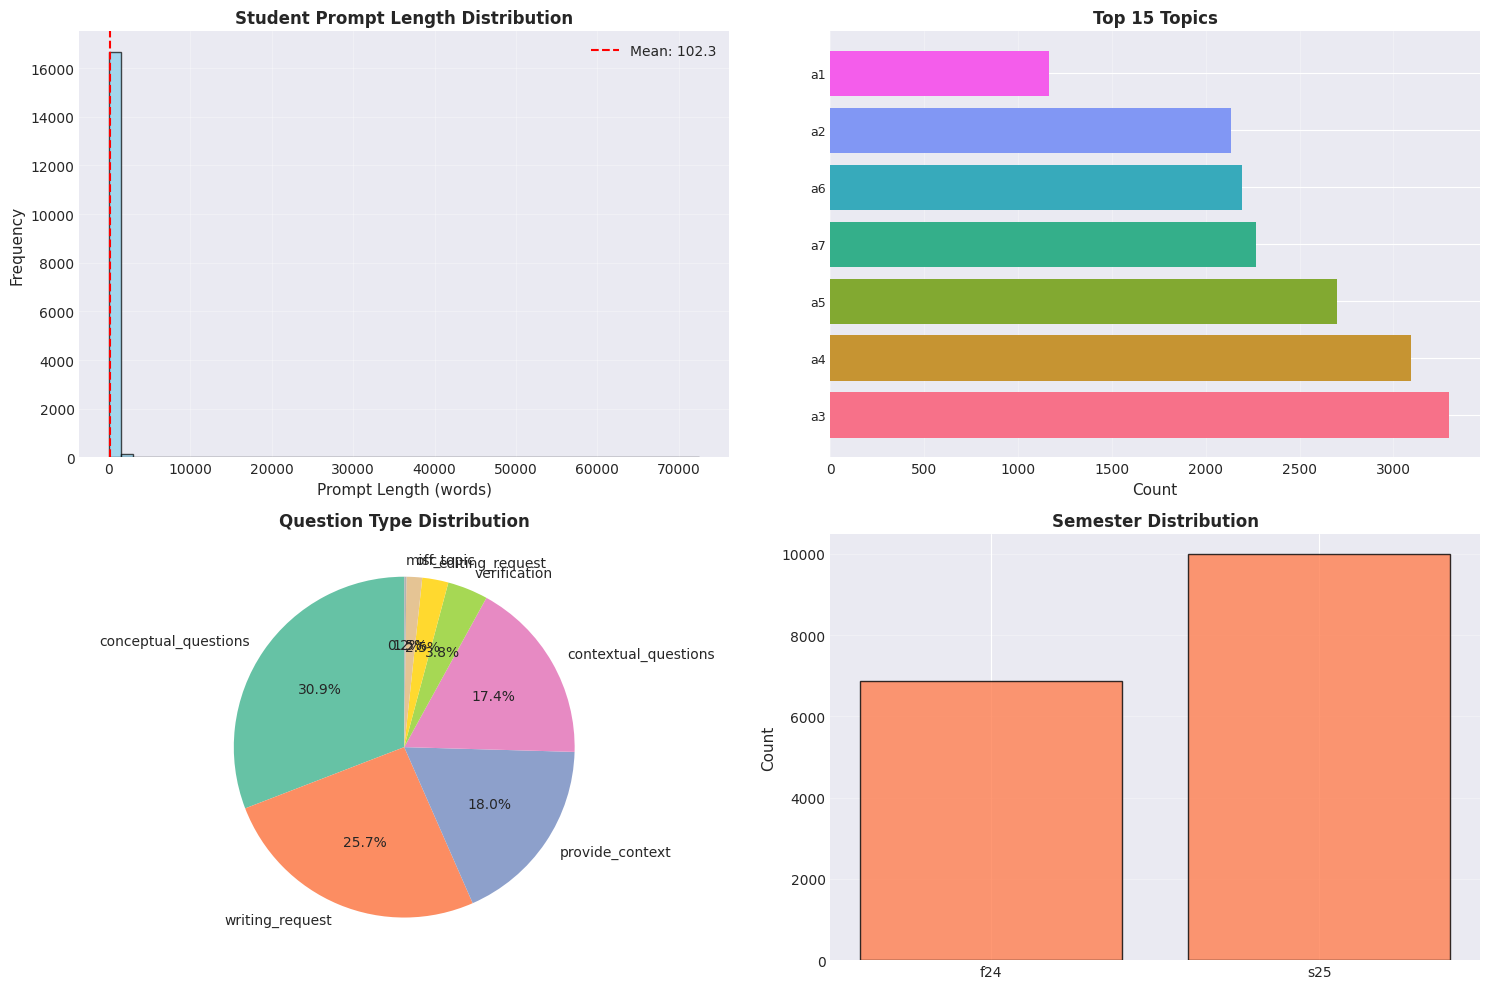

In [23]:
# Prompt length statistics
prompt_lengths = [len(p.split()) for p in prompts]

print("\n=== PROMPT STATISTICS ===")
print(f"  Total prompts: {len(prompts)}")
print(f"  Mean length: {np.mean(prompt_lengths):.1f} words")
print(f"  Median length: {np.median(prompt_lengths):.1f} words")
print(f"  Std deviation: {np.std(prompt_lengths):.1f} words")
print(f"  Min length: {np.min(prompt_lengths)} words")
print(f"  Max length: {np.max(prompt_lengths)} words")
print(f"  95th percentile: {np.percentile(prompt_lengths, 95):.1f} words")

# Plot distributions
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Prompt length distribution
axes[0, 0].hist(prompt_lengths, bins=50, edgecolor='black', alpha=0.7, color='skyblue')
axes[0, 0].axvline(np.mean(prompt_lengths), color='red', linestyle='--',
                   label=f'Mean: {np.mean(prompt_lengths):.1f}')
axes[0, 0].set_xlabel('Prompt Length (words)', fontsize=11)
axes[0, 0].set_ylabel('Frequency', fontsize=11)
axes[0, 0].set_title('Student Prompt Length Distribution', fontsize=12, fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# Topic distribution (top 15)
top_topics = sorted(topic_counts.items(), key=lambda x: x[1], reverse=True)[:15]
topic_names = [t[0] for t in top_topics]
topic_values = [t[1] for t in top_topics]
axes[0, 1].barh(range(len(topic_names)), topic_values, color=sns.color_palette("husl", len(topic_names)))
axes[0, 1].set_yticks(range(len(topic_names)))
axes[0, 1].set_yticklabels(topic_names, fontsize=9)
axes[0, 1].set_xlabel('Count', fontsize=11)
axes[0, 1].set_title('Top 15 Topics', fontsize=12, fontweight='bold')
axes[0, 1].grid(axis='x', alpha=0.3)

# Question type distribution
label_items = sorted(label_counts.items(), key=lambda x: x[1], reverse=True)
label_names = [l[0] for l in label_items]
label_values = [l[1] for l in label_items]
colors = sns.color_palette("Set2", len(label_names))
axes[1, 0].pie(label_values, labels=label_names, autopct='%1.1f%%', colors=colors, startangle=90)
axes[1, 0].set_title('Question Type Distribution', fontsize=12, fontweight='bold')

# Semester distribution
sem_items = sorted(semester_counts.items())
sem_names = [s[0] for s in sem_items]
sem_values = [s[1] for s in sem_items]
axes[1, 1].bar(range(len(sem_names)), sem_values, color='coral', edgecolor='black', alpha=0.8)
axes[1, 1].set_xticks(range(len(sem_names)))
axes[1, 1].set_xticklabels(sem_names, fontsize=10)
axes[1, 1].set_ylabel('Count', fontsize=11)
axes[1, 1].set_title('Semester Distribution', fontsize=12, fontweight='bold')
axes[1, 1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(RESULTS_DIR / f"{EXPERIMENT_ID}_data_exploration.png", dpi=150, bbox_inches='tight')
plt.show()

## 4. Prompt Extraction & Preprocessing

Extract student prompts and metadata for clustering.

In [24]:
# Extract prompts with metadata - FILTER ONLY QUESTIONS for FAQ generation
prompts_data = []
total_prompts = 0
filtered_questions = 0

for idx, item in enumerate(train_data):
    prompt_text = item['prompt'].strip()
    total_prompts += 1

    # Filter only questions (check llm_label or if prompt ends with '?')
    llm_label = item['llm_label']['label']
    is_question = (
        'question' in llm_label.lower() or  # Check if labeled as a question type
        prompt_text.endswith('?') or         # Check if ends with question mark
        any(prompt_text.lower().startswith(q) for q in ['what', 'how', 'why', 'when', 'where', 'who', 'which', 'can', 'could', 'would', 'should', 'is', 'are', 'do', 'does'])
    )

    # Apply filters: must be a question and longer than 10 characters
    if is_question and len(prompt_text) > 10:
        filtered_questions += 1
        prompts_data.append({
            'index': idx,
            'prompt': prompt_text,
            'response': item['response'],
            'topic': item['topic'],
            'llm_label': llm_label,
            'llm_justification': item['llm_label']['justification'],
            'semester': item['semester'],
            'chat_title': item['chatTitle'],
            'interaction_count': item['interactionCount']
        })

# Apply sampling if configured (for faster experimentation)
if SAMPLE_SIZE is not None and len(prompts_data) > SAMPLE_SIZE:
    np.random.seed(RANDOM_SEED)
    sample_indices = np.random.choice(len(prompts_data), size=SAMPLE_SIZE, replace=False)
    prompts_data = [prompts_data[i] for i in sample_indices]
    print(f"⚠️  Sampled {SAMPLE_SIZE} questions from {filtered_questions} for faster clustering")

# Extract prompt texts for clustering
prompt_texts = [p['prompt'] for p in prompts_data]

print(f"\nTotal prompts in dataset: {total_prompts}")

print(f"Filtered questions for FAQ: {filtered_questions} ({filtered_questions/total_prompts*100:.1f}%)")
print(f"   Topic: {p['topic']}, Type: {p['llm_label']}")

print(f"Questions used for clustering: {len(prompts_data)}")
print(f"\n{i+1}. {p['prompt'][:100]}...")

if SAMPLE_SIZE and len(prompts_data) < filtered_questions:
    p = prompts_data[i]
    print(f"  (Random sample of {SAMPLE_SIZE} for performance)")
for i in range(min(5, len(prompts_data))):
    p = prompts_data[i]
    print(f"{i+1}. {p['prompt'][:100]}...")

print(f"Non-question prompts excluded: {total_prompts - filtered_questions}")
print("\nSample questions:")

⚠️  Sampled 2000 questions from 9268 for faster clustering

Total prompts in dataset: 16851
Filtered questions for FAQ: 9268 (55.0%)
   Topic: a4, Type: conceptual_questions>Other Concept
Questions used for clustering: 2000

31. Assignment 3: Equation of a Slime
In this assignment, we'll get our hands dirty with data and create...
  (Random sample of 2000 for performance)
1. how to find size of data_set...
2. how do I get the first element of the first column of a pd dataaframe...
3. print the label name of the predicted class...
4. how would i test this code...
5. how can i nicely print the ngram frequency tables in the terminal...
Non-question prompts excluded: 7583

Sample questions:


## 5. Vectorization (TF-IDF)

Convert prompts to TF-IDF vectors for clustering.

In [25]:
# Initialize TF-IDF vectorizer (from-scratch implementation)
vectorizer = TFIDFVectorizer(
    max_features=MAX_FEATURES,
    min_df=MIN_DF
)

# Fit and transform prompts
print("Vectorizing prompts...")
X = vectorizer.fit_transform(prompt_texts)

print(f"TF-IDF matrix shape: {X.shape}")
print(f"Vocabulary size: {len(vectorizer.vocabulary_)}")
print(f"Sparsity: {(1.0 - np.count_nonzero(X) / X.size) * 100:.2f}%")

# Display top TF-IDF terms
feature_names = vectorizer.get_feature_names()
tfidf_scores = np.asarray(X.sum(axis=0)).flatten()
top_indices = np.argsort(tfidf_scores)[::-1][:30]

print("\nTop 30 terms by TF-IDF score:")
for i, idx in enumerate(top_indices, 1):
    print(f"  {i:2d}. {feature_names[idx]:20s} (score: {tfidf_scores[idx]:.3f})")

Vectorizing prompts...
TF-IDF matrix shape: (2000, 1000)
Vocabulary size: 1000
Sparsity: 99.08%

Top 30 terms by TF-IDF score:
   1. model                (score: 44.658)
   2. score                (score: 44.094)
   3. code                 (score: 42.194)
   4. dataset              (score: 37.140)
   5. python               (score: 37.024)
   6. data                 (score: 36.473)
   7. rows                 (score: 32.842)
   8. pandas               (score: 32.069)
   9. columns              (score: 31.128)
  10. explain              (score: 29.575)
  11. column               (score: 28.531)
  12. output               (score: 28.339)
  13. sequence             (score: 28.028)
  14. values               (score: 27.733)
  15. function             (score: 26.956)
  16. return               (score: 25.344)
  17. tensor               (score: 24.729)
  18. table                (score: 24.503)
  19. prefix               (score: 24.324)
  20. node                 (score: 24.059)
  21. set    

## 6. Clustering with K-Means

Apply K-Means clustering with different k values to find optimal grouping.

**K-Means Objective**: Minimize $SSE = \sum_{i=1}^{k} \sum_{x \in S_i} ||x - c_i||^2$

In [26]:
# Storage for K-Means results
kmeans_models = {}
kmeans_sse = []
kmeans_silhouette = []

for k in K_RANGE:
    print(f"\n{'='*60}")
    print(f"K-Means with k={k} clusters")
    print(f"{'='*60}")

    # Initialize K-Means with K-Means++ initialization
    kmeans = KMeans(
        n_clusters=k,
        max_iter=MAX_ITER,
        init='kmeans++',
        random_state=RANDOM_SEED
    )

    # Fit
    kmeans.fit(X)

    # Get labels and centroids
    labels = kmeans.labels_
    centroids = kmeans.centroids_

    # Store model
    kmeans_models[k] = {
        'model': kmeans,
        'labels': labels,
        'centroids': centroids
    }

    # Metrics
    sse = kmeans.sse_history_[-1] if len(kmeans.sse_history_) > 0 else kmeans.inertia_
    silhouette = silhouette_score(X, labels)

    kmeans_sse.append(sse)
    kmeans_silhouette.append(silhouette)

    print(f"SSE (Sum of Squared Errors): {sse:.4f}")
    print(f"Silhouette Score: {silhouette:.4f}")
    print(f"Iterations: {kmeans.n_iter_}")

    # Cluster sizes
    unique, counts = np.unique(labels, return_counts=True)
    print("\nCluster sizes:")
    for cluster_id, count in zip(unique, counts):
        print(f"  Cluster {cluster_id}: {count} prompts ({count/len(labels)*100:.1f}%)")

print(f"\n{'='*60}")
print("K-Means clustering complete for all k values")
print(f"{'='*60}")


K-Means with k=3 clusters
SSE (Sum of Squared Errors): 1773.1452
Silhouette Score: 0.0235
Iterations: 24

Cluster sizes:
  Cluster 0: 407 prompts (20.3%)
  Cluster 1: 1415 prompts (70.8%)
  Cluster 2: 178 prompts (8.9%)

K-Means with k=5 clusters
SSE (Sum of Squared Errors): 1733.4822
Silhouette Score: 0.0279
Iterations: 26

Cluster sizes:
  Cluster 0: 250 prompts (12.5%)
  Cluster 1: 1338 prompts (66.9%)
  Cluster 2: 174 prompts (8.7%)
  Cluster 3: 170 prompts (8.5%)
  Cluster 4: 68 prompts (3.4%)

K-Means with k=7 clusters
SSE (Sum of Squared Errors): 1712.8319
Silhouette Score: 0.0305
Iterations: 28

Cluster sizes:
  Cluster 0: 228 prompts (11.4%)
  Cluster 1: 1251 prompts (62.5%)
  Cluster 2: 181 prompts (9.0%)
  Cluster 3: 160 prompts (8.0%)
  Cluster 4: 68 prompts (3.4%)
  Cluster 5: 29 prompts (1.5%)
  Cluster 6: 83 prompts (4.2%)

K-Means with k=10 clusters
SSE (Sum of Squared Errors): 1675.0027
Silhouette Score: 0.0374
Iterations: 26

Cluster sizes:
  Cluster 0: 68 prompts (3

## 7. Clustering with Fuzzy C-Means (FCM)

Apply FCM for soft clustering where prompts can partially belong to multiple clusters.

**FCM Objective**: Minimize $J_m = \sum_{i=1}^{c} \sum_{j=1}^{n} u_{ij}^m ||x_j - c_i||^2$ where $m > 1$ is fuzziness parameter.

In [27]:
# Storage for FCM results
fcm_models = {}
fcm_jm = []
fcm_fpc = []

for k in K_RANGE:
    print(f"\n{'='*60}")
    print(f"Fuzzy C-Means with c={k} clusters, m={FCM_M}")
    print(f"{'='*60}")

    # Initialize FCM
    fcm = FuzzyCMeans(
        n_clusters=k,
        m=FCM_M,
        max_iter=MAX_ITER,
        random_state=RANDOM_SEED
    )

    # Fit
    fcm.fit(X)

    # Get hard labels and membership
    labels = fcm.labels_
    membership = fcm.membership_
    centroids = fcm.centroids_

    # Store model
    fcm_models[k] = {
        'model': fcm,
        'labels': labels,
        'membership': membership,
        'centroids': centroids
    }

    # Metrics
    jm = fcm.jm_history_[-1] if len(fcm.jm_history_) > 0 else 0
    fpc = fuzzy_partition_coefficient(membership)

    fcm_jm.append(jm)
    fcm_fpc.append(fpc)

    print(f"Objective function J_m: {jm:.4f}")
    print(f"Fuzzy Partition Coefficient: {fpc:.4f}")
    print(f"Iterations: {fcm.n_iter_}")

    # Cluster sizes
    unique, counts = np.unique(labels, return_counts=True)
    print("\nCluster sizes (hard labels):")
    for cluster_id, count in zip(unique, counts):
        print(f"  Cluster {cluster_id}: {count} prompts ({count/len(labels)*100:.1f}%)")

print(f"\n{'='*60}")
print("FCM clustering complete for all c values")
print(f"{'='*60}")


Fuzzy C-Means with c=3 clusters, m=1.5
Objective function J_m: 1048.0993
Fuzzy Partition Coefficient: 0.3333
Iterations: 3

Cluster sizes (hard labels):
  Cluster 0: 995 prompts (49.8%)
  Cluster 1: 873 prompts (43.6%)
  Cluster 2: 132 prompts (6.6%)

Fuzzy C-Means with c=5 clusters, m=1.5
Objective function J_m: 811.8543
Fuzzy Partition Coefficient: 0.2000
Iterations: 3

Cluster sizes (hard labels):
  Cluster 0: 12 prompts (0.6%)
  Cluster 1: 490 prompts (24.5%)
  Cluster 2: 1082 prompts (54.1%)
  Cluster 3: 14 prompts (0.7%)
  Cluster 4: 402 prompts (20.1%)

Fuzzy C-Means with c=7 clusters, m=1.5
Objective function J_m: 686.1421
Fuzzy Partition Coefficient: 0.1429
Iterations: 3

Cluster sizes (hard labels):
  Cluster 0: 1 prompts (0.1%)
  Cluster 1: 61 prompts (3.0%)
  Cluster 2: 1071 prompts (53.5%)
  Cluster 3: 8 prompts (0.4%)
  Cluster 4: 698 prompts (34.9%)
  Cluster 5: 134 prompts (6.7%)
  Cluster 6: 27 prompts (1.4%)

Fuzzy C-Means with c=10 clusters, m=1.5
Objective function

## 8. Model Evaluation & Selection

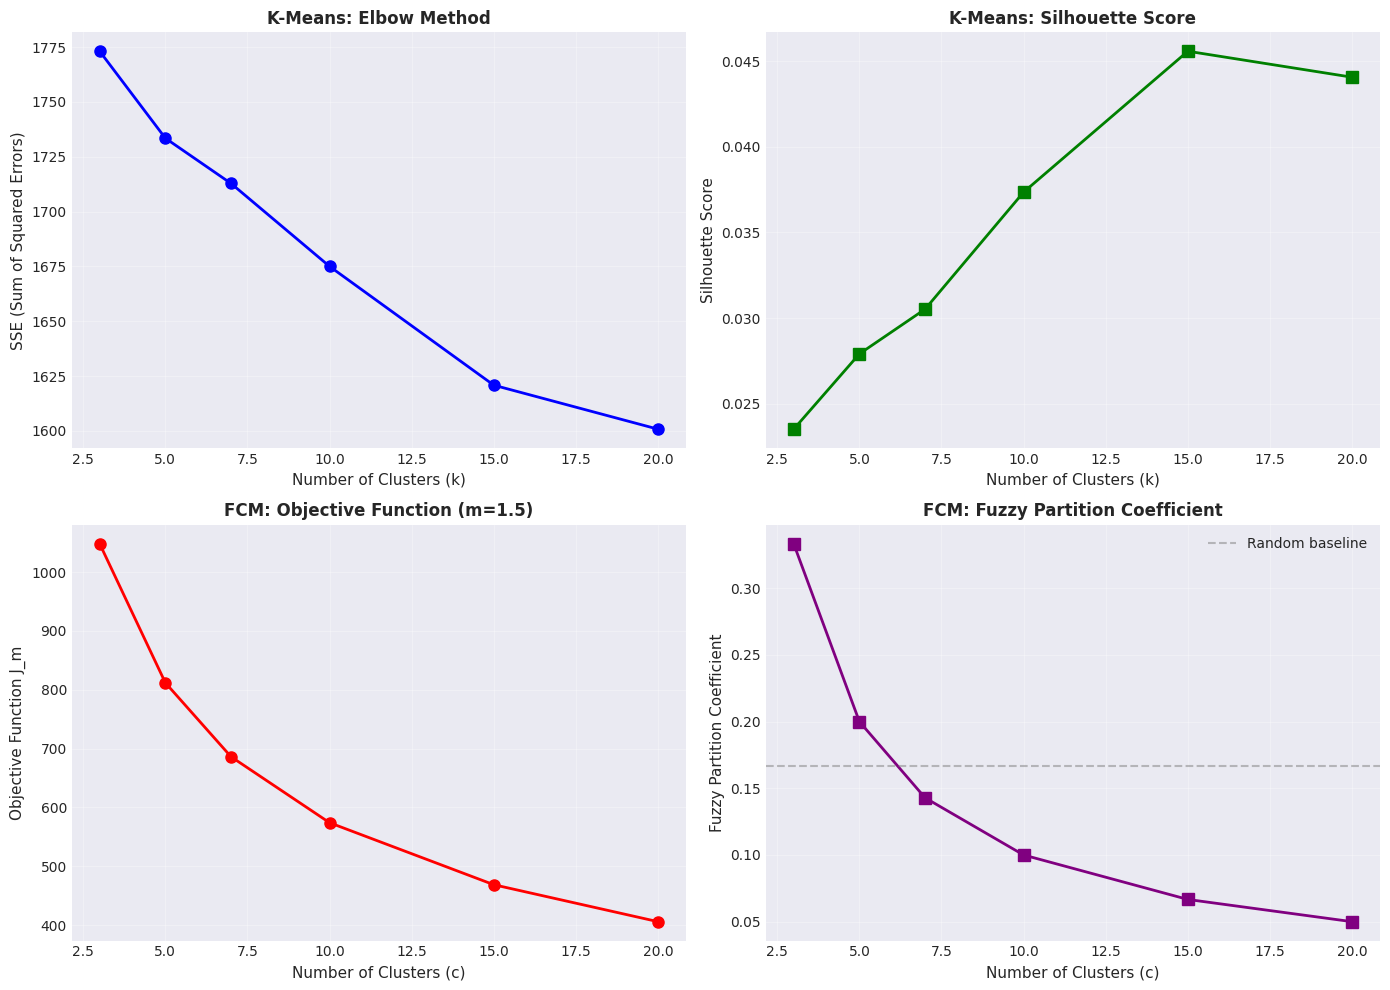


Optimal k (elbow method): 15
Optimal k (max silhouette): 15


In [28]:
# Create comparison plots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# K-Means SSE (Elbow plot)
axes[0, 0].plot(K_RANGE, kmeans_sse, marker='o', linewidth=2, markersize=8, color='blue')
axes[0, 0].set_xlabel('Number of Clusters (k)', fontsize=11)
axes[0, 0].set_ylabel('SSE (Sum of Squared Errors)', fontsize=11)
axes[0, 0].set_title('K-Means: Elbow Method', fontsize=12, fontweight='bold')
axes[0, 0].grid(True, alpha=0.3)

# K-Means Silhouette Score
axes[0, 1].plot(K_RANGE, kmeans_silhouette, marker='s', linewidth=2, markersize=8, color='green')
axes[0, 1].set_xlabel('Number of Clusters (k)', fontsize=11)
axes[0, 1].set_ylabel('Silhouette Score', fontsize=11)
axes[0, 1].set_title('K-Means: Silhouette Score', fontsize=12, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3)

# FCM Objective Function
axes[1, 0].plot(K_RANGE, fcm_jm, marker='o', linewidth=2, markersize=8, color='red')
axes[1, 0].set_xlabel('Number of Clusters (c)', fontsize=11)
axes[1, 0].set_ylabel('Objective Function J_m', fontsize=11)
axes[1, 0].set_title(f'FCM: Objective Function (m={FCM_M})', fontsize=12, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3)

# FCM Fuzzy Partition Coefficient
axes[1, 1].plot(K_RANGE, fcm_fpc, marker='s', linewidth=2, markersize=8, color='purple')
axes[1, 1].set_xlabel('Number of Clusters (c)', fontsize=11)
axes[1, 1].set_ylabel('Fuzzy Partition Coefficient', fontsize=11)
axes[1, 1].set_title('FCM: Fuzzy Partition Coefficient', fontsize=12, fontweight='bold')
axes[1, 1].axhline(y=1.0/len(K_RANGE), color='gray', linestyle='--', alpha=0.5, label='Random baseline')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(RESULTS_DIR / f"{EXPERIMENT_ID}_clustering_metrics.png", dpi=150, bbox_inches='tight')
plt.show()

# Find optimal k using elbow method
sse_array = np.array(kmeans_sse)
diffs = np.diff(sse_array)
second_diffs = np.diff(diffs)
elbow_idx = np.argmax(np.abs(second_diffs)) + 1
optimal_k_elbow = K_RANGE[elbow_idx]

# Find optimal k using silhouette
optimal_k_silhouette = K_RANGE[np.argmax(kmeans_silhouette)]

print(f"\nOptimal k (elbow method): {optimal_k_elbow}")
print(f"Optimal k (max silhouette): {optimal_k_silhouette}")

## 9. Select Best Model & Analyze Clusters

In [29]:
# Select optimal k (default: silhouette-based)
SELECTED_K = optimal_k_silhouette
# SELECTED_K = 10  # Uncomment to manually override

print(f"Selected k = {SELECTED_K} clusters")

# Choose clustering method (K-Means by default)
USE_KMEANS = True  # Set to False for FCM

if USE_KMEANS:
    selected_model = kmeans_models[SELECTED_K]
    labels = selected_model['labels']
    centroids = selected_model['centroids']
    method_name = "K-Means"
else:
    selected_model = fcm_models[SELECTED_K]
    labels = selected_model['labels']
    centroids = selected_model['centroids']
    membership = selected_model['membership']
    method_name = "FCM"

print(f"Using {method_name} with {SELECTED_K} clusters")
print(f"Centroids shape: {centroids.shape}")

Selected k = 15 clusters
Using K-Means with 15 clusters
Centroids shape: (15, 1000)


In [30]:
# Analyze each cluster
print(f"\n{'='*70}")
print(f"CLUSTER ANALYSIS ({method_name}, k={SELECTED_K})")
print(f"{'='*70}\n")

cluster_analysis = {}

for cluster_id in range(SELECTED_K):
    # Get prompts in this cluster
    cluster_mask = labels == cluster_id
    cluster_prompts_data = [p for i, p in enumerate(prompts_data) if cluster_mask[i]]

    print(f"Cluster {cluster_id + 1}:")
    print(f"  Size: {len(cluster_prompts_data)} prompts ({len(cluster_prompts_data)/len(labels)*100:.1f}%)")

    # Find prompts closest to centroid
    cluster_vectors = X[cluster_mask]
    centroid = centroids[cluster_id].reshape(1, -1)
    distances = np.linalg.norm(cluster_vectors - centroid, axis=1)
    closest_indices = np.argsort(distances)[:TOP_N_QUESTIONS_PER_CLUSTER]

    # Representative prompts
    representative_prompts = [cluster_prompts_data[i] for i in closest_indices]
    representative_distances = [distances[i] for i in closest_indices]

    print("\n  Representative prompts (closest to centroid):")
    for rank, (p, dist) in enumerate(zip(representative_prompts[:5], representative_distances[:5]), 1):
        print(f"    {rank}. {p['prompt'][:100]}...")
        print(f"       Topic: {p['topic']}, Type: {p['llm_label']}, Distance: {dist:.4f}\n")

    # Identify common topics and question types in cluster
    topics_in_cluster = [p['topic'] for p in cluster_prompts_data]
    types_in_cluster = [p['llm_label'].split('>')[0] for p in cluster_prompts_data]

    topic_dist = defaultdict(int)
    for t in topics_in_cluster:
        topic_dist[t] += 1

    type_dist = defaultdict(int)
    for t in types_in_cluster:
        type_dist[t] += 1

    print("  Common topics:")
    for topic, count in sorted(topic_dist.items(), key=lambda x: x[1], reverse=True)[:3]:
        print(f"    - {topic}: {count} prompts ({count/len(cluster_prompts_data)*100:.1f}%)")

    print("\n  Common question types:")
    for qtype, count in sorted(type_dist.items(), key=lambda x: x[1], reverse=True)[:3]:
        print(f"    - {qtype}: {count} prompts ({count/len(cluster_prompts_data)*100:.1f}%)")

    # Store analysis
    cluster_analysis[cluster_id] = {
        'size': len(cluster_prompts_data),
        'representative_prompts': representative_prompts,
        'representative_distances': representative_distances,
        'top_topics': dict(sorted(topic_dist.items(), key=lambda x: x[1], reverse=True)[:5]),
        'top_types': dict(sorted(type_dist.items(), key=lambda x: x[1], reverse=True)[:5]),
        'centroid': centroid.flatten()
    }

    print(f"\n{'-'*70}\n")


CLUSTER ANALYSIS (K-Means, k=15)

Cluster 1:
  Size: 73 prompts (3.6%)

  Representative prompts (closest to centroid):
    1. how to test a made up data point'...
       Topic: a4, Type: contextual_questions>Code Explanation, Distance: 0.6835

    2. How to use get_dummies to transform the data set to change categorical data but not get rid of numer...
       Topic: a3, Type: conceptual_questions>Python Library, Distance: 0.8193

    3. how to print all data...
       Topic: a3, Type: conceptual_questions>Python Library, Distance: 0.8265

    4. how do I use the astype(int) on columns from a given index to the end of the data frame...
       Topic: a1, Type: conceptual_questions>Programming Language, Distance: 0.8325

    5. Provided a set of data, could you convert the data into a well-formatted markdown document-- free fr...
       Topic: a4, Type: writing_request>Code/Data Conversion, Distance: 0.8470

  Common topics:
    - a3: 32 prompts (43.8%)
    - a4: 22 prompts (30.1%)
    

## 10. Generate FAQ Structure

Create FAQ entries from representative prompts in each cluster.

In [31]:
# Generate FAQ structure
faq_structure = {
    'metadata': {
        'dataset': DATASET_NAME,
        'experiment_id': EXPERIMENT_ID,
        'clustering_method': method_name,
        'n_clusters': SELECTED_K,
        'n_prompts_total': len(prompts_data),
        'generation_date': datetime.now().isoformat()
    },
    'faq_categories': []
}

for cluster_id in range(SELECTED_K):
    analysis = cluster_analysis[cluster_id]

    # Create category name from top topics and types
    top_topic = list(analysis['top_topics'].keys())[0] if analysis['top_topics'] else "General"
    top_type = list(analysis['top_types'].keys())[0] if analysis['top_types'] else "Questions"
    category_name = f"Category {cluster_id + 1}: {top_type} ({top_topic})"

    faq_category = {
        'category_id': cluster_id,
        'category_name': category_name,
        'cluster_size': analysis['size'],
        'dominant_topics': analysis['top_topics'],
        'dominant_types': analysis['top_types'],
        'faq_entries': []
    }

    # Add representative prompts as FAQ entries
    for q_idx, (prompt_data, distance) in enumerate(zip(
        analysis['representative_prompts'],
        analysis['representative_distances']
    )):
        faq_entry = {
            'faq_id': f"C{cluster_id}_Q{q_idx}",
            'question': prompt_data['prompt'],
            'answer': prompt_data['response'][:500] + "...",  # Truncate long answers
            'centroid_distance': float(distance),
            'related_topic': prompt_data['topic'],
            'question_type': prompt_data['llm_label'],
            'semester': prompt_data['semester'],
            'chat_title': prompt_data['chat_title']
        }
        faq_category['faq_entries'].append(faq_entry)

    faq_structure['faq_categories'].append(faq_category)

# Display FAQ structure (first 3 categories)
print("\n" + "="*70)
print("GENERATED FAQ STRUCTURE (First 3 Categories)")
print("="*70 + "\n")

for category in faq_structure['faq_categories'][:3]:
    print(f"\n{category['category_name']}")
    print(f"  ({category['cluster_size']} prompts in cluster)\n")
    print(f"  Top topics: {list(category['dominant_topics'].keys())[:3]}")
    print(f"  Top types: {list(category['dominant_types'].keys())[:3]}\n")

    for entry in category['faq_entries'][:3]:  # Show first 3 FAQs per category
        print(f"  Q: {entry['question'][:80]}...")
        print(f"     ID: {entry['faq_id']}, Topic: {entry['related_topic']}, Type: {entry['question_type'][:30]}...")
        print(f"     Distance: {entry['centroid_distance']:.4f}\n")
    print("-" * 70)


GENERATED FAQ STRUCTURE (First 3 Categories)


Category 1: conceptual_questions (a3)
  (73 prompts in cluster)

  Top topics: ['a3', 'a4', 'a7']
  Top types: ['conceptual_questions', 'contextual_questions', 'writing_request']

  Q: how to test a made up data point'...
     ID: C0_Q0, Topic: a4, Type: contextual_questions>Code Expl...
     Distance: 0.6835

  Q: How to use get_dummies to transform the data set to change categorical data but ...
     ID: C0_Q1, Topic: a3, Type: conceptual_questions>Python Li...
     Distance: 0.8193

  Q: how to print all data...
     ID: C0_Q2, Topic: a3, Type: conceptual_questions>Python Li...
     Distance: 0.8265

----------------------------------------------------------------------

Category 2: contextual_questions (a3)
  (45 prompts in cluster)

  Top topics: ['a3', 'a2', 'a4']
  Top types: ['contextual_questions', 'conceptual_questions']

  Q: speficically explain why axis=1? why 1 not any other numbers?...
     ID: C1_Q0, Topic: a4, Type: conce

## 11. Visualizations with Custom Plots

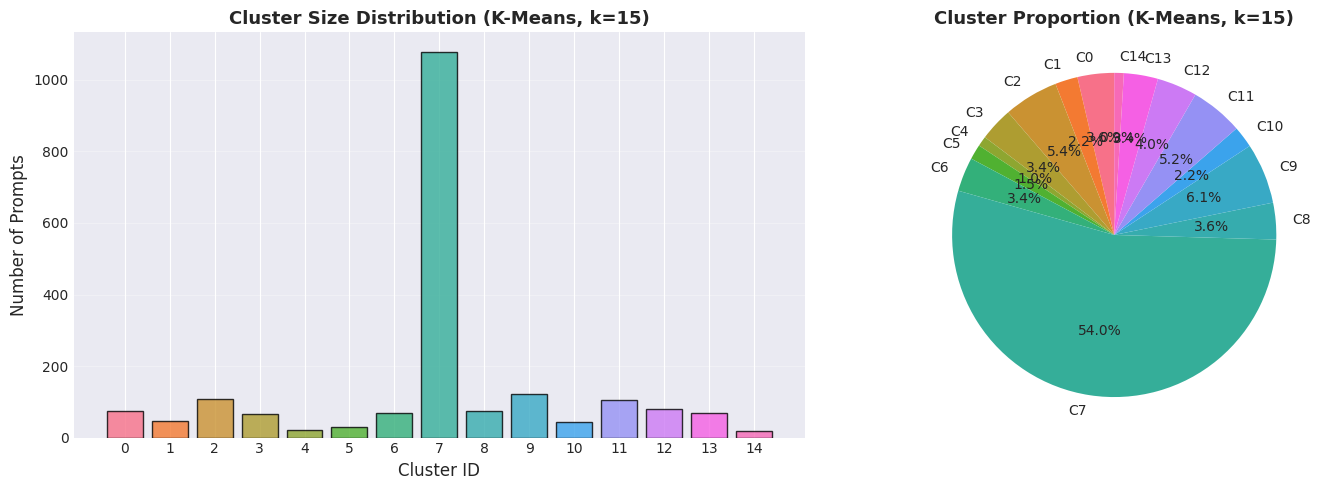

In [32]:
# Cluster size distribution
unique_labels, label_counts = np.unique(labels, return_counts=True)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Bar plot
axes[0].bar(unique_labels, label_counts, color=sns.color_palette("husl", SELECTED_K),
            edgecolor='black', alpha=0.8)
axes[0].set_xlabel('Cluster ID', fontsize=12)
axes[0].set_ylabel('Number of Prompts', fontsize=12)
axes[0].set_title(f'Cluster Size Distribution ({method_name}, k={SELECTED_K})',
                  fontsize=13, fontweight='bold')
axes[0].set_xticks(unique_labels)
axes[0].grid(axis='y', alpha=0.3)

# Pie chart
axes[1].pie(label_counts, labels=[f"C{i}" for i in unique_labels],
            autopct='%1.1f%%', colors=sns.color_palette("husl", SELECTED_K),
            startangle=90)
axes[1].set_title(f'Cluster Proportion ({method_name}, k={SELECTED_K})',
                  fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig(RESULTS_DIR / f"{EXPERIMENT_ID}_cluster_distribution_k{SELECTED_K}.png",
            dpi=150, bbox_inches='tight')
plt.show()

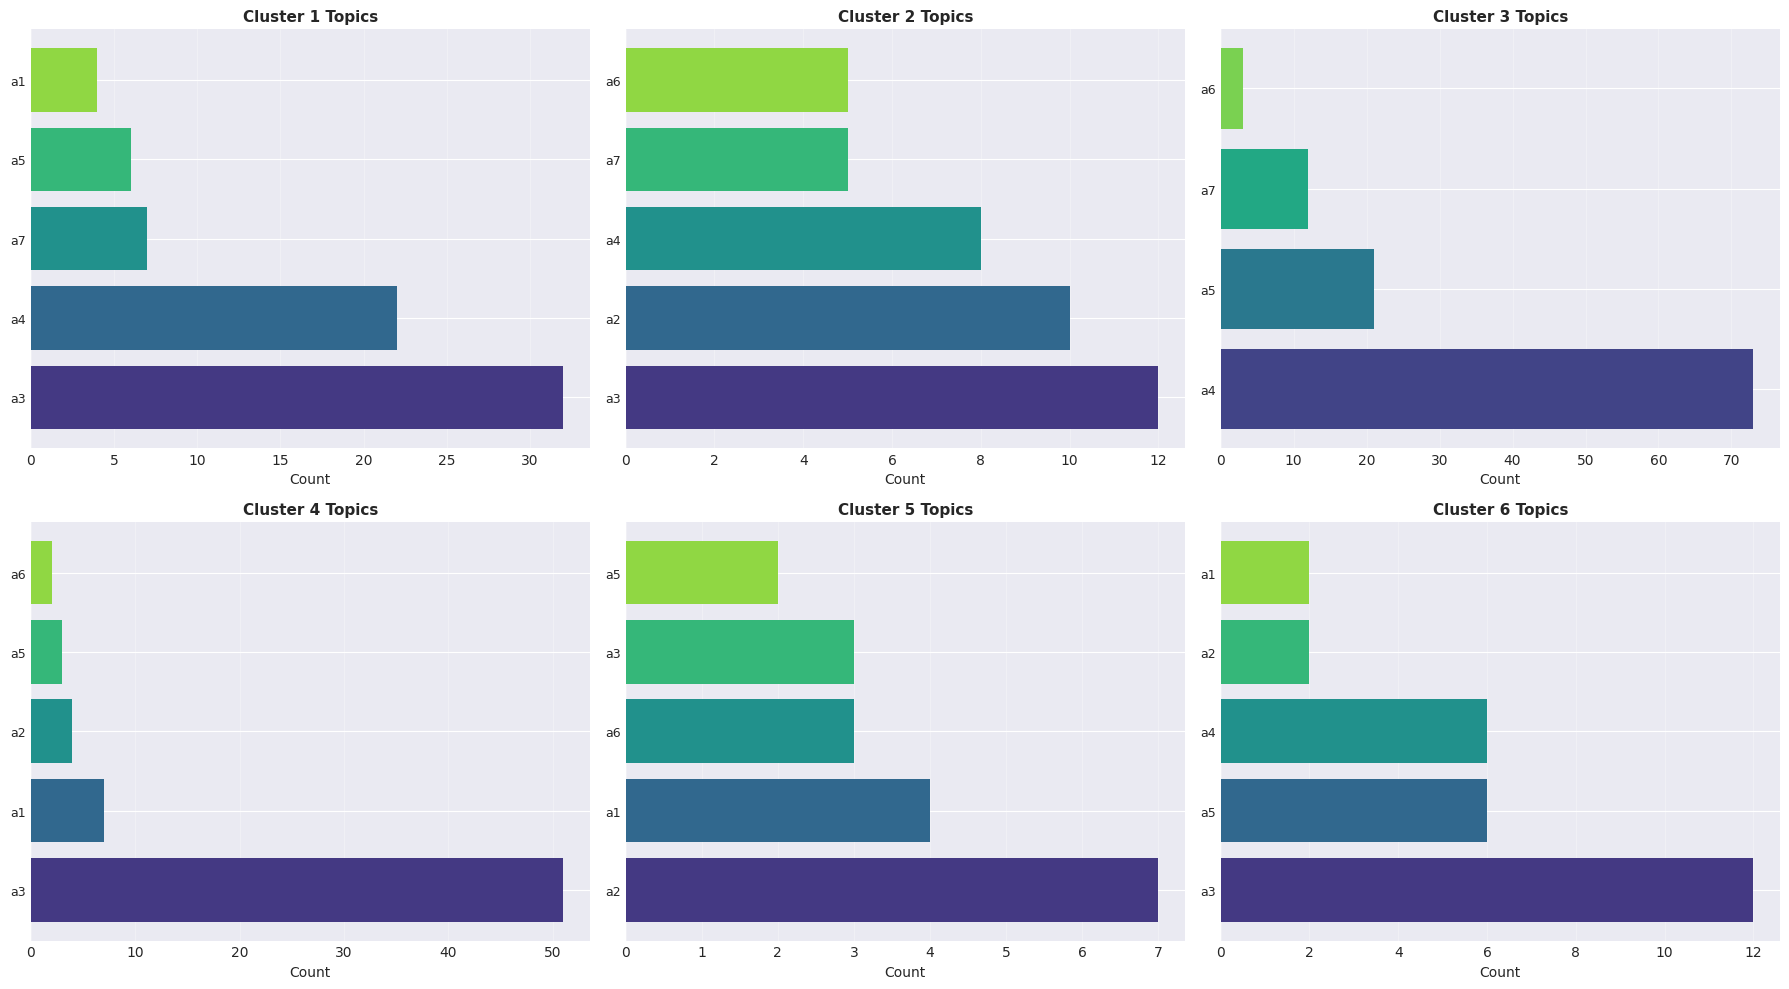

In [33]:
# Topic distribution per cluster
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for cluster_id in range(min(6, SELECTED_K)):
    analysis = cluster_analysis[cluster_id]
    topics = list(analysis['top_topics'].keys())
    counts = list(analysis['top_topics'].values())

    axes[cluster_id].barh(range(len(topics)), counts,
                          color=sns.color_palette("viridis", len(topics)))
    axes[cluster_id].set_yticks(range(len(topics)))
    axes[cluster_id].set_yticklabels(topics, fontsize=9)
    axes[cluster_id].set_xlabel('Count', fontsize=10)
    axes[cluster_id].set_title(f'Cluster {cluster_id + 1} Topics', fontsize=11, fontweight='bold')
    axes[cluster_id].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig(RESULTS_DIR / f"{EXPERIMENT_ID}_topic_distributions.png", dpi=150, bbox_inches='tight')
plt.show()

In [34]:
# If using FCM, create membership heatmap
if not USE_KMEANS and SELECTED_K in fcm_models:
    membership = fcm_models[SELECTED_K]['membership']
    plot_fcm_membership_heatmap(
        membership,
        str(RESULTS_DIR / f"{EXPERIMENT_ID}_fcm_membership_k{SELECTED_K}.png"),
        sample_size=100
    )

## 12. Save Results & Export Centroids

In [35]:
# Save cluster centroids (for difficulty estimation in chatbot)
np.save(RESULTS_DIR / f"{EXPERIMENT_ID}_centroids_k{SELECTED_K}.npy", centroids)

# Save cluster labels
np.save(RESULTS_DIR / f"{EXPERIMENT_ID}_labels_k{SELECTED_K}.npy", labels)

# Save vocabulary
with open(RESULTS_DIR / f"{EXPERIMENT_ID}_vocabulary.txt", 'w', encoding='utf-8') as f:
    for word in feature_names:
        f.write(f"{word}\n")

# Save FAQ structure
with open(RESULTS_DIR / f"{EXPERIMENT_ID}_faq_structure.json", 'w', encoding='utf-8') as f:
    json.dump(faq_structure, f, indent=2, ensure_ascii=False)

# Save cluster analysis
analysis_export = {
    'experiment_id': EXPERIMENT_ID,
    'dataset': DATASET_NAME,
    'method': method_name,
    'n_clusters': SELECTED_K,
    'n_prompts': len(prompts_data),
    'metrics': {
        'sse': float(kmeans_sse[K_RANGE.index(SELECTED_K)]),
        'silhouette': float(kmeans_silhouette[K_RANGE.index(SELECTED_K)])
    },
    'clusters': {}
}

for cluster_id, analysis in cluster_analysis.items():
    # Extract just essential data (avoid storing full prompts)
    analysis_export['clusters'][f'cluster_{cluster_id}'] = {
        'size': analysis['size'],
        'top_topics': analysis['top_topics'],
        'top_types': analysis['top_types'],
        'representative_prompts': [
            p['prompt'][:200] for p in analysis['representative_prompts'][:5]
        ]
    }

with open(RESULTS_DIR / f"{EXPERIMENT_ID}_analysis.json", 'w', encoding='utf-8') as f:
    json.dump(analysis_export, f, indent=2, ensure_ascii=False)

print(f"✓ Results saved to {RESULTS_DIR}")
print(f"  - Centroids: centroids_k{SELECTED_K}.npy")
print(f"  - Labels: labels_k{SELECTED_K}.npy")
print("  - Vocabulary: vocabulary.txt")
print("  - FAQ Structure: faq_structure.json")
print("  - Analysis: analysis.json")
print("  - Figures: .png files")

✓ Results saved to ../results/faq_generation
  - Centroids: centroids_k15.npy
  - Labels: labels_k15.npy
  - Vocabulary: vocabulary.txt
  - FAQ Structure: faq_structure.json
  - Analysis: analysis.json
  - Figures: .png files


## 13. Integration with TFG-Chatbot

### How to Use These Results:

**1. Load Centroids for Question Classification:**
```python
# In chatbot/logic/tools/tools.py
import numpy as np
from pathlib import Path

centroids = np.load("results/faq_generation/studychat_faq_..._centroids_k10.npy")
vectorizer = TFIDFVectorizer()  # Load same vectorizer
vectorizer.fit(training_prompts)  # Use same vocabulary

def classify_question(question: str) -> int:
    """Classify question to nearest centroid cluster."""
    q_vec = vectorizer.transform([question])
    distances = np.linalg.norm(q_vec - centroids, axis=1)
    return np.argmin(distances)
```

**2. Use FAQ Structure:**
- Load `faq_structure.json` into MongoDB for retrieval
- Use in RAG tool to find similar FAQ entries
- Leverage `llm_label` field for question type classification
- Adapt English responses to Spanish for TFG-Chatbot

**3. Topic-Based Routing:**
- Map StudyChat topics (a1-a4) to TFG subjects
- Use cluster analysis to route questions to appropriate modules
- Integrate `question_type` classification (conceptual, contextual, writing)

**4. Difficulty Estimation:**
- Label clusters by difficulty (easy/medium/hard) based on `llm_label` complexity
- Train difficulty classifier using centroids
- Use `semester` field as difficulty proxy (early vs late semester)

## 14. Conclusions

### Key Findings:
- Optimal number of clusters: **k = ?** (update after running)
- Clustering method used: **K-Means / FCM**
- Main question categories identified: (describe clusters)

### Dataset Insights:
- **Question Types**: Dominated by contextual questions, conceptual questions, and writing requests
- **Topics**: Assignment-specific queries (a1-a4) form major clusters
- **Semester Pattern**: Different question complexity across semesters (f24, etc.)
- **Interaction Patterns**: Multi-turn conversations provide rich context

### Comparison with CIMA Dataset:
- **Scale**: StudyChat (16K) vs CIMA (smaller)
- **Language**: English vs Italian
- **Domain**: General academic vs grammar tutoring
- **Labels**: Rich LLM labels vs topic metadata

### Next Steps:
- [ ] Label clusters with difficulty levels (easy/medium/hard)
- [ ] Compare K-Means vs FCM for question classification accuracy
- [ ] Test with embeddings (Ollama) instead of TF-IDF
- [ ] Cross-lingual adaptation: English → Spanish FAQs
- [ ] Integrate with TFG-Chatbot RAG system
- [ ] Use `llm_label` for supervised difficulty estimation
- [ ] Analyze multi-turn conversation patterns for better context handling